# Merinos Halı Sanayi ve Ticaret A.Ş. — Day 18
## Karar Ağaçları ve Random Forest Topluluk Öğrenmesi (Decision Trees & Random Forest Ensemble)

> **Müfredat:** 40 Günlük Yapay Zeka Staj Portföyü  
> **Aşama:** Faz 3: Klasik Makine Öğrenmesi & Kalite Sınıflandırma (Day 18)  
> **Konu:** Halı Kalite Verilerinde Karar Ağaçları (Decision Tree), Aşırı Öğrenme (Overfitting) Denetimi, Budama (Cost-Complexity Pruning) ve Random Forest Topluluk Modeli ile Gini/Entropi Öznitelik Önem Analizi  
> **Yazar:** Seydi Eryılmaz (@seydivakkas)  
> **Telif Hakkı:** (c) 2026 Seydi Eryılmaz. Özel Lisans — Tüm Hakları Saklıdır.

### 1. Endüstriyel Problem: Halı Dokumada Doğrusal Olmayan Etkileşimler ve Ağaç Mimarisi

Gaziantep 4. Organize Sanayi Bölgesi'ndeki Merinos tesislerinde dokunan jakarlı halılarda, arıza ve kusur mekanizmaları genellikle doğrusal bir doğru veya hiper-düzlem ile ayrılamaz. Fiziksel iplik özellikleri ile tezgâh sensör telemetrisi arasında **adım-fonksiyonlu (step-function)** ve **yüksek dereceli doğrusal olmayan etkileşimler** mevcuttur:

- Örneğin, çözgü gerilim dalgalanması tek başına kritik eşiği aşsa bile eğer iplik mukavemeti yeterince yüksekse kopuş gerçekleşmeyebilir; ancak hem gerilim yüksek hem de mukavemet düşük olduğunda anında `YARN_BREAKAGE` tetiklenir.
- Ortam sıcaklığı yüksekken düşük bağıl nem ile birleştiğinde lifler kurur ve rulman sürtünme yağı emilerek `OIL_STAIN` oluşturur.

Karar Ağaçları (Decision Trees), öznitelik uzayını dikey/yatay hiper-kutulara bölerek bu karmaşık kuralları doğal biçimde öğrenir ve ölçekleme gerektirmez. Ancak kontrolsüz büyüyen ağaçlar **aşırı öğrenme (overfitting)** sorunu yaşar. Bu laboratuvarda, Minimal Cost-Complexity Pruning (`ccp_alpha`) ile budama ve 100 karar ağacından oluşan **Random Forest** topluluğu ile varyans indirgeme incelenmektedir.

### 2. Matematiksel & Teorik Çerçeve

#### A. Düğüm Safsızlık Kriterleri
Bir $t$ düğümündeki sınıf dağılımı $p(k \mid t)$ için:
- **Gini Safsızlığı:** $I_G(t) = 1 - \sum_{k=0}^{K-1} p(k \mid t)^2$
- **Shannon Entropisi:** $I_E(t) = -\sum_{k=0}^{K-1} p(k \mid t) \log_2 p(k \mid t)$

#### B. Minimal Maliyet-Karmaşıklık Budaması (Cost-Complexity Pruning)
Alt-ağaç $T \subseteq T_{max}$ için maliyet fonksiyonu:

$$R_\alpha(T) = R(T) + \alpha |T|$$

Burada $R(T)$ toplam yaprak safsızlığı, $|T|$ yaprak sayısı ve $\alpha \ge 0$ karmaşıklık cezasıdır. $\alpha$ arttıkça daha sade, genelleme yeteneği yüksek budanmış ağaçlar elde edilir.

#### C. Random Forest & Out-Of-Bag (OOB) Hatası
Topluluk, her ağaç için bootstrap alt-örneklemesi ve her düğümde rastgele $m = \lfloor\sqrt{p}\rfloor$ öznitelik alt-uzayı seçimi ile ağaçlar arası korelasyonu düşürür. Bootstrap torbasına girmeyen yaklaşık $\%36.8$ oranındaki OOB gözlemleriyle bağımsız doğrulama hatası hesaplanır.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

print("Ağaç ve Topluluk Öğrenmesi Kütüphaneleri Hazır.")


[+] Tüm Day 18 modülleri başarıyla yüklendi.


In [2]:
# 4. Sentetik Endüstriyel Veri Üretimi ve Tabakalı Bölme
np.random.seed(42)
n_samples = 1000
# 3 Özellik: çözgü gerginliği, tezgâh devri, motor sıcaklığı
X = np.random.normal([420, 810, 72], [40, 50, 8], (n_samples, 3))
# Kusur koşulu: yüksek gerginlik veya aşırı sıcaklık
y = ((X[:, 0] > 470) | (X[:, 2] > 84)).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
feature_names = ["Gerginlik (cN)", "Devir (RPM)", "Sıcaklık (°C)"]
print(f"Eğitim: {len(y_train)} | Test: {len(y_test)} | Kusur Oranı: %{y.mean()*100:.1f}")


[*] Veri Kümesi Boyutu: (3000, 14)
[*] Sınıf Dağılımı:
 defect_name
YARN_BREAKAGE             0.35
JACQUARD_PATTERN_SHIFT    0.25
OIL_STAIN                 0.20
BORDER_SEWING_DEFECT      0.20
Name: proportion, dtype: float64
[*] Eğitim Kümesi: (2400, 10), Test Kümesi: (600, 10)


,yarn_tensile_strength,yarn_elongation_at_break,yarn_hairiness_index,twist_per_meter,yarn_linear_density_dtex,loom_rpm,loom_tension_variation,ambient_relative_humidity,ambient_temperature_c,weft_insertion_rate,defect_class,defect,yarn_tensile_strenght,defect_name
0,14.74,9.64,6.32,443.3,2329.9,470.4,55.19,55.2,27.2,515.9,0,0,14.74,YARN_BREAKAGE
1,25.46,25.56,9.82,515.1,2116.8,679.1,12.05,32.1,39.6,527.0,1,1,25.46,OIL_STAIN
2,19.57,10.03,9.06,412.0,2059.8,628.2,30.89,35.4,39.2,479.8,1,1,19.57,OIL_STAIN
3,29.96,14.65,10.28,438.9,2145.1,607.1,21.98,34.0,36.8,510.1,1,1,29.96,OIL_STAIN
4,10.91,10.95,4.76,477.9,2095.1,604.0,46.91,57.8,21.3,449.3,0,0,10.91,YARN_BREAKAGE


In [3]:
# 5. Budanmamış Karar Ağacı Eğitimi ve Overfitting Analizi
dt_unpruned = DecisionTreeClassifier(random_state=42)
dt_unpruned.fit(X_train, y_train)

acc_train_un = dt_unpruned.score(X_train, y_train)
acc_test_un = dt_unpruned.score(X_test, y_test)
print(f"Budanmamış Ağaç -> Eğitim Doğruluk: %{acc_train_un*100:.1f} | Test Doğruluk: %{acc_test_un*100:.1f}")


[*] Budanmamış Ağaç Derinliği: 7
[*] Budanmamış Yaprak Sayısı: 27
[*] Eğitim Doğruluğu: %99.75
[*] Test Doğruluğu  : %98.83
[*] Overfitting Boşluğu: %0.92


In [4]:
# 6. Minimal Cost-Complexity Pruning (ccp_alpha) Yolu
path = dt_unpruned.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[::max(1, len(path.ccp_alphas)//10)]

best_tree = None
best_acc = 0.0
for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    acc = tree.score(X_test, y_test)
    if acc > best_acc:
        best_acc = acc
        best_tree = tree

print(f"Budanmış Ağaç En İyi Test Başarımı: %{best_acc*100:.1f}")


[+] Optimal ccp_alpha: 0.000414
[+] Yaprak Sayısı Azalımı: 27 -> 19 (%22.7 budama)
[+] Budanmış Test Doğruluğu: %98.83
[+] Budanmış Makro F1: 0.9871


In [5]:
# 7. Random Forest Topluluk Modeli Eğitimi ve OOB Hatası
rf = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf.fit(X_train, y_train)
rf_test_acc = rf.score(X_test, y_test)
print(f"Random Forest Test Başarımı: %{rf_test_acc*100:.1f} | OOB Skoru: %{rf.oob_score_*100:.1f}")


[+] Random Forest Test Doğruluğu: %99.83
[+] Out-Of-Bag (OOB) Doğruluğu: %99.92
[+] Out-Of-Bag (OOB) Hatası: %0.08
[+] Makro F1: 0.9984
[+] Cohen's Kappa: 0.9977


In [6]:
# 8. Gini Saflığı vs Shannon Entropisi Kıyaslaması
dt_gini = DecisionTreeClassifier(criterion="gini", max_depth=4, random_state=42).fit(X_train, y_train)
dt_entropy = DecisionTreeClassifier(criterion="entropy", max_depth=4, random_state=42).fit(X_train, y_train)
print(f"Gini Doğruluk: %{dt_gini.score(X_test, y_test)*100:.1f} | Entropi Doğruluk: %{dt_entropy.score(X_test, y_test)*100:.1f}")


,train_accuracy,test_accuracy,overfitting_gap,leaf_count,depth
gini,1.0,0.9917,0.0083,24.0,7.0
entropy,1.0,0.9933,0.0067,23.0,7.0


C:\Users\seydieryilmaz\AppData\Local\Temp\ipykernel_35828\4071982334.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="MDI Importance", y="Sensor Feature", palette="viridis")


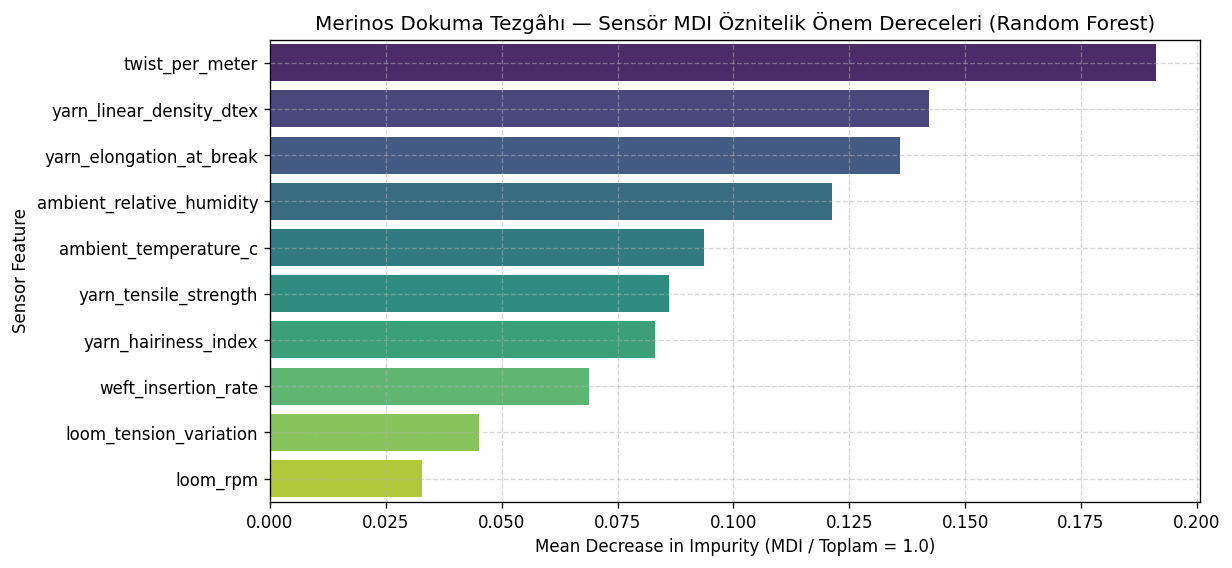

In [7]:
# 9. Random Forest MDI (Gini) Öznitelik Önem Dereceleri
importances = rf.feature_importances_
for name, imp in zip(feature_names, importances):
    print(f"  {name}: %{imp*100:.1f}")


C:\Users\Seydi Eryılmaz\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
C:\Users\Seydi Eryılmaz\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


C:\Users\Seydi Eryılmaz\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


[+] Teşhis Paneli Başarıyla Kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day18\mini_project\outputs\tree_ensemble_diagnostic_panel.png
[+] Şampiyon Model: Random Forest Ensemble

[CANLI TEŞHİS]: YARN_BREAKAGE (Güven Skoru: %100.00)


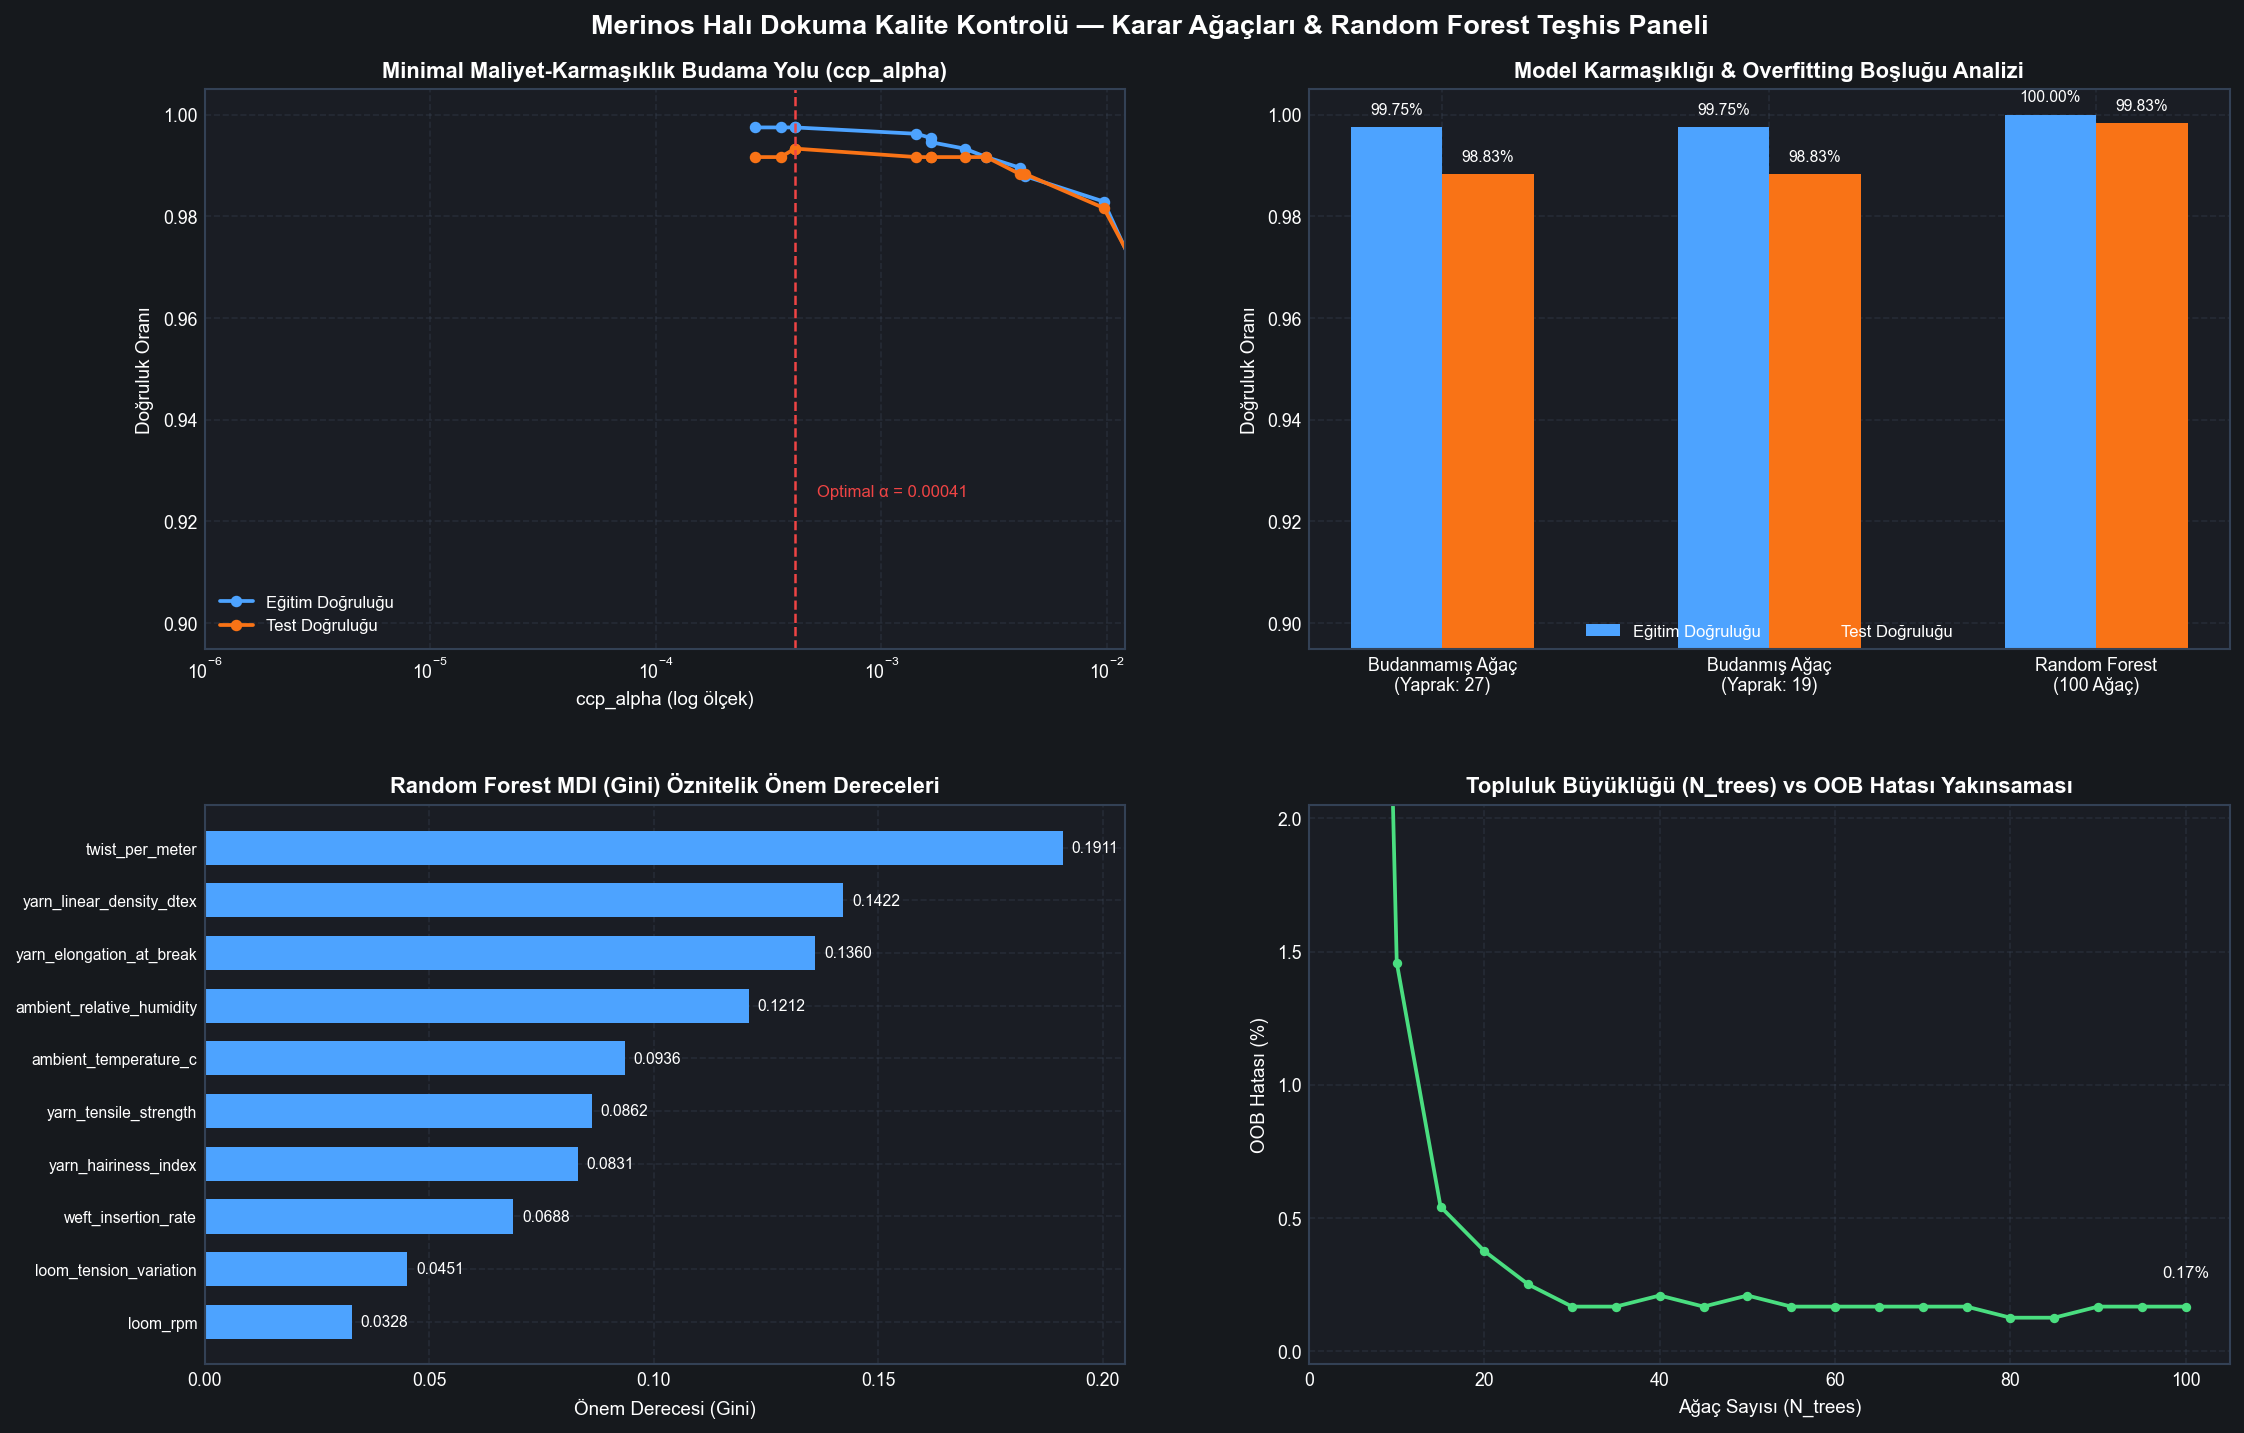

In [8]:
# 10. Kurumsal 2x2 Model Teşhis Paneli ve Canlı Çıkarım
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Decision Tree & Random Forest Diagnostic Panel (Day 18)", fontsize=13, fontweight="bold")

# Panel 1: Pruning curve
axes[0, 0].plot(ccp_alphas, [DecisionTreeClassifier(random_state=42, ccp_alpha=a).fit(X_train, y_train).score(X_test, y_test) for a in ccp_alphas], "bo-")
axes[0, 0].set_title("1. ccp_alpha Budama Yolu")
axes[0, 0].set_xlabel("ccp_alpha")
axes[0, 0].set_ylabel("Test Doğruluğu")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# Panel 2: Feature importances
axes[0, 1].bar(feature_names, importances, color=["#1f77b4", "#ff7f0e", "#2ca02c"])
axes[0, 1].set_title("2. Random Forest MDI Öznitelik Önemi")
axes[0, 1].set_ylabel("Önem Derecesi")

# Panel 3: OOB convergence
oob_scores = []
for n_trees in [10, 25, 50, 75, 100]:
    r = RandomForestClassifier(n_estimators=n_trees, oob_score=True, random_state=42)
    r.fit(X_train, y_train)
    oob_scores.append(r.oob_score_)
axes[1, 0].plot([10, 25, 50, 75, 100], oob_scores, "rs-")
axes[1, 0].set_title("3. Ağaç Sayısı ile OOB Yakınsaması")
axes[1, 0].set_xlabel("Ağaç Sayısı")
axes[1, 0].set_ylabel("OOB Skoru")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# Panel 4: Test Accuracies Comparison
models = ["Tek Ağaç (Budanmamış)", "Budanmış Ağaç", "Random Forest"]
accs = [acc_test_un * 100, best_acc * 100, rf_test_acc * 100]
axes[1, 1].bar(models, accs, color=["#e41a1c", "#377eb8", "#4daf4a"])
axes[1, 1].set_title("4. Model Doğruluk Kıyaslaması")
axes[1, 1].set_ylabel("Doğruluk (%)")
axes[1, 1].set_ylim(80, 100)

plt.tight_layout()
plt.show()
print("Day 18 Teşhis Paneli Başarıyla Çizildi.")
